# SVM Regression
...depends on activity_threshold

## Load and split data

In [26]:
import pandas as pd

df_pos = pd.read_csv('../../data/inputs/descriptors_positive_staphylococcus.csv')
# df_neg_01 = pd.read_csv('../../data/inputs/descriptors_negative_01_dataset.csv')
df_neg = pd.read_csv('../../data/inputs/descriptors_negative_02_dataset.csv')
# df_neg_03 = pd.read_csv('../../data/inputs/descriptors_negative_03_dataset.csv')

# concat
df = pd.concat([df_pos, df_neg])

In [27]:
# split data
from sklearn.model_selection import train_test_split
from data_cleaner import preprocess_features

X = df.drop(['SEQUENCE', 'ACTIVITY'], axis=1)
y = df['ACTIVITY']
X = preprocess_features(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

,AF1,AF2,AF3,AF4,AF5,BLOSUM1,BLOSUM2,BLOSUM3,BLOSUM4,BLOSUM5,...,VSTPV2,VSTPV3,VSTPV4,VSTPV5,VSTPV6,Z1,Z2,Z3,Z4,Z5
count,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,...,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000,707.000000
mean,0.013236,-0.095148,0.025713,0.344299,0.209417,0.053235,-0.207761,-0.166635,-0.058829,0.071462,...,0.223139,0.384205,-0.273404,0.208229,-0.262688,0.006477,-0.402782,-0.532579,-0.084830,0.161265
std,0.293476,0.293286,0.518387,0.254220,0.518086,0.273173,0.245782,0.242905,0.204427,0.240784,...,0.212759,0.186743,0.238300,0.227599,0.219636,0.766653,0.680018,0.595565,0.569844,0.292519
min,-1.256054,-1.192502,-2.309459,-0.843603,-1.409909,-1.232000,-1.088000,-0.870000,-1.110000,-0.895000,...,-0.605714,-0.395000,-0.988333,-0.825000,-1.240000,-3.084286,-2.084762,-3.045556,-1.680000,-0.966471
25%,-0.164214,-0.285512,-0.263243,0.210162,-0.108239,-0.112333,-0.348351,-0.314372,-0.160366,-0.073507,...,0.100270,0.303765,-0.431833,0.083535,-0.396351,-0.432364,-0.797899,-0.877974,-0.433737,0.038750
50%,0.006917,-0.111759,0.027332,0.353784,0.189628,0.080000,-0.235625,-0.189667,-0.050909,0.052571,...,0.220667,0.393333,-0.292000,0.219524,-0.254574,0.047391,-0.463000,-0.514091,-0.133571,0.188800
75%,0.178918,0.071989,0.334739,0.513991,0.530736,0.221111,-0.093608,-0.036827,0.053154,0.205709,...,0.349270,0.490784,-0.144708,0.344251,-0.130000,0.491875,-0.104647,-0.197919,0.202362,0.324744
max,1.300561,1.455382,1.810092,1.085286,2.555108,0.924286,1.235000,0.663580,0.541538,1.151111,...,1.056667,0.948000,0.540000,1.002308,0.435556,2.644444,3.220000,1.450000,2.715000,1.420000


## SVM

In [29]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Set the parameters by cross-validation
tuned_parameters = [{'kernel': ['rbf'], 'gamma': [1e-3, 1e-4], 'C': [1, 10, 100, 1000]} ]

# grid search
rgs = GridSearchCV(SVR(), tuned_parameters, cv=5)
rgs.fit(X_train, y_train)

print("Best parameters set found on development set:")

print(rgs.best_params_)

print("Grid scores on development set:")
means = rgs.cv_results_['mean_test_score']
stds = rgs.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, rgs.cv_results_['params']):
    print("%0.3f (+/-%0.03f) for %r"
          % (mean, std * 2, params))

Best parameters set found on development set:
{'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
Grid scores on development set:
-0.955 (+/-0.098) for {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
-0.959 (+/-0.098) for {'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
-0.918 (+/-0.099) for {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
-0.954 (+/-0.098) for {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
-0.576 (+/-0.104) for {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
-0.909 (+/-0.100) for {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
0.303 (+/-0.075) for {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
-0.501 (+/-0.115) for {'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}


In [ ]:
# RMSE, MAE instead of ...


Accuracy: 0.8135593220338984
Precision: 0.7264150943396226
Recall: 0.9506172839506173
AUC: 0.824266975308642


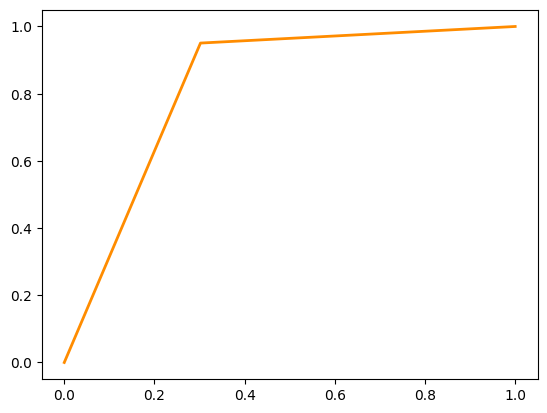

In [44]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

activity_threshold = 5000

model = rgs.best_estimator_
y_pred = model.predict(X_test)
y_pred_binary = y_pred > activity_threshold
y_test_binary = y_test > activity_threshold
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_binary)}")
print(f"Precision: {precision_score(y_test_binary, y_pred_binary)}")
print(f"Recall: {recall_score(y_test_binary, y_pred_binary)}")
print(f"AUC: {roc_auc_score(y_test_binary, y_pred_binary)}")
# plot ROC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_binary)
roc_auc = auc(fpr, tpr)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)


## Histogram - visualization of y_pred and y_test

In [45]:
y_test.describe()

count      177.000000
mean      4583.910390
std       4989.117431
min          0.117000
25%          8.300000
50%         32.000000
75%      10000.000000
max      10000.000000
Name: ACTIVITY, dtype: float64

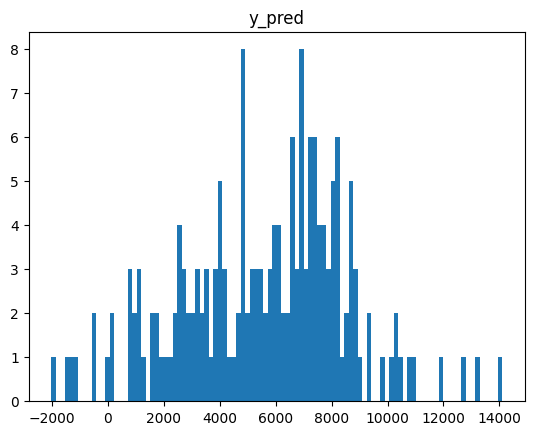

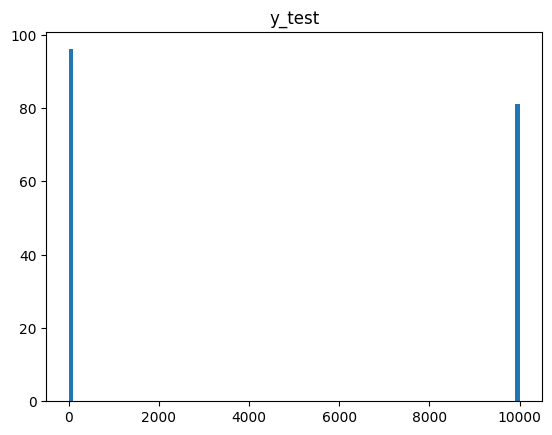

In [47]:
#hist y_pred, y_test
plt.hist(y_pred, bins=100)
plt.title('y_pred')
plt.show()
plt.hist(y_test, bins=100)
plt.title('y_test')
plt.show()